<a href="https://colab.research.google.com/github/alisony755/DS4400/blob/main/HW4/DS3000_HW4_Problem1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 1

In [40]:
# Import numpy, pandas, sklearn, and matplotlib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

In [41]:
# Get spambase data
!pip install -U ucimlrepo

from ucimlrepo import fetch_ucirepo

# Fetch dataset
spambase = fetch_ucirepo(id=94)

# Data (as pandas dataframes)
X = spambase.data.features
y = spambase.data.targets

# Print metadata
print(spambase.metadata)

# Print variable information
print(spambase.variables)

{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In [42]:
# Convert dataset to numpy arrays
X = X.values
y = y.values.ravel()  # flatten target to shape (n,)

# Split dataset into training (75%) and testing (25%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [43]:
def compute_metrics(y_true, y_pred, y_probs, dataset_name="Dataset"):
  """ Computes and prints classification metrics for a model.

  Args:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted class labels
    y_probs (numpy.ndarray): Predicted probabilities for positive class
    dataset_name (str): Name of dataset (e.g., "Training", "Testing")

  Returns:
    None: prints accuracy, error, f1, and auc
  """

  # Compute accuracy
  accuracy = accuracy_score(y_true, y_pred)

  # Compute error rate
  error = 1 - accuracy

  # Compute F1 score
  f1 = f1_score(y_true, y_pred)

  # Compute AUC score
  auc = roc_auc_score(y_true, y_probs)

  # Print formatted output
  print(f"{dataset_name} Metrics")
  print(f"Accuracy: {accuracy}")
  print(f"Error: {error}")
  print(f"F1 Score: {f1}")
  print(f"AUC: {auc}")

  return None

### 1.1

In [44]:
# Create decision tree using entropy (information gain)
tree_entropy = DecisionTreeClassifier(
    criterion='entropy',  # Use information gain
    random_state=42
)

# Train model on training data
tree_entropy.fit(X_train, y_train)

# Predict class labels for training and testing sets
y_train_pred = tree_entropy.predict(X_train)
y_test_pred = tree_entropy.predict(X_test)

# Predict probabilities needed for AUC
y_train_probs = tree_entropy.predict_proba(X_train)[:, 1]
y_test_probs = tree_entropy.predict_proba(X_test)[:, 1]

# Compute metrics for training set
train_metrics = compute_metrics(
    y_train,
    y_train_pred,
    y_train_probs,
    dataset_name="Training"
)

print(f"\n")

# Compute metrics for testing set
test_metrics = compute_metrics(
    y_test,
    y_test_pred,
    y_test_probs,
    dataset_name="Testing"
)

Training Metrics
Accuracy: 0.9994202898550725
Error: 0.0005797101449275255
F1 Score: 0.9992520568436799
AUC: 0.9999992922498527


Testing Metrics
Accuracy: 0.9235447437011295
Error: 0.07645525629887051
F1 Score: 0.905982905982906
AUC: 0.9189489255683587


### 1.2

In [45]:
# Create decision tree using Gini index
tree_gini = DecisionTreeClassifier(
    criterion='gini',  # se Gini impurity
    random_state=42
)

# Train model
tree_gini.fit(X_train, y_train)

# Predictions
y_train_pred_gini = tree_gini.predict(X_train)
y_test_pred_gini = tree_gini.predict(X_test)

# Probability predictions
y_train_probs_gini = tree_gini.predict_proba(X_train)[:, 1]
y_test_probs_gini = tree_gini.predict_proba(X_test)[:, 1]

# Compute training metrics
compute_metrics(
    y_train,
    y_train_pred_gini,
    y_train_probs_gini,
    dataset_name="Training"
)

print(f"\n")

# Compute testing metrics
compute_metrics(
    y_test,
    y_test_pred_gini,
    y_test_probs_gini,
    dataset_name="Testing"
)

Training Metrics
Accuracy: 0.9994202898550725
Error: 0.0005797101449275255
F1 Score: 0.9992520568436799
AUC: 0.9999992922498527


Testing Metrics
Accuracy: 0.9148566463944396
Error: 0.08514335360556036
F1 Score: 0.8977035490605428
AUC: 0.9153706010588601


### 1.3

In [46]:
# Define range of tree depths to test
depths = range(1, 21)

# Lists to store training and testing errors
train_errors = []
test_errors = []

# Loop over different depths
for d in depths:

    # Create decision tree with max depth = d
    tree = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=d,
        random_state=42
    )

    # Train model
    tree.fit(X_train, y_train)

    # Make predictions
    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)

    # Compute errors (1 - accuracy)
    train_error = 1 - accuracy_score(y_train, y_train_pred)
    test_error = 1 - accuracy_score(y_test, y_test_pred)

    # Store errors
    train_errors.append(train_error)
    test_errors.append(test_error)

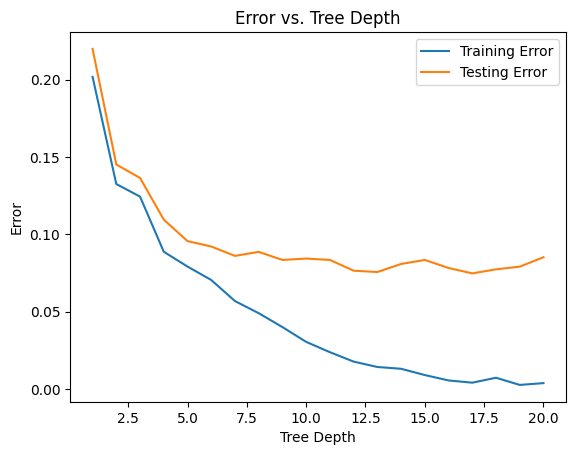

In [47]:
# Plot training and testing error vs depth
plt.figure()

# Plot training error curve
plt.plot(depths, train_errors, label="Training Error")

# Plot testing error curve
plt.plot(depths, test_errors, label="Testing Error")

# Label axes
plt.xlabel("Tree Depth")
plt.ylabel("Error")

# Add title and legend
plt.title("Error vs. Tree Depth")
plt.legend()

# Show plot
plt.show()